## 1. Evaluate the dataset for suitability to apply a Linear Regression Algorithm

Prior to applying the linear regression model, it is imperative to first assess whether the dataset meets the key assumptions of the model. The dataset "insurance.csv" will be used throught the analysis. This dataset contains 1338 0bservation and 7 features (age, sex, bmi, children, smoker, region, charges). The target variable  is charges (medical costs). We proceed to evaluate the following assumptions:

### 1.1 Linearity

Linear regression assumes a linear realtionship between predictors and the target. We wil examine scatter plots of numeric features against chargers, coloured by smoker.


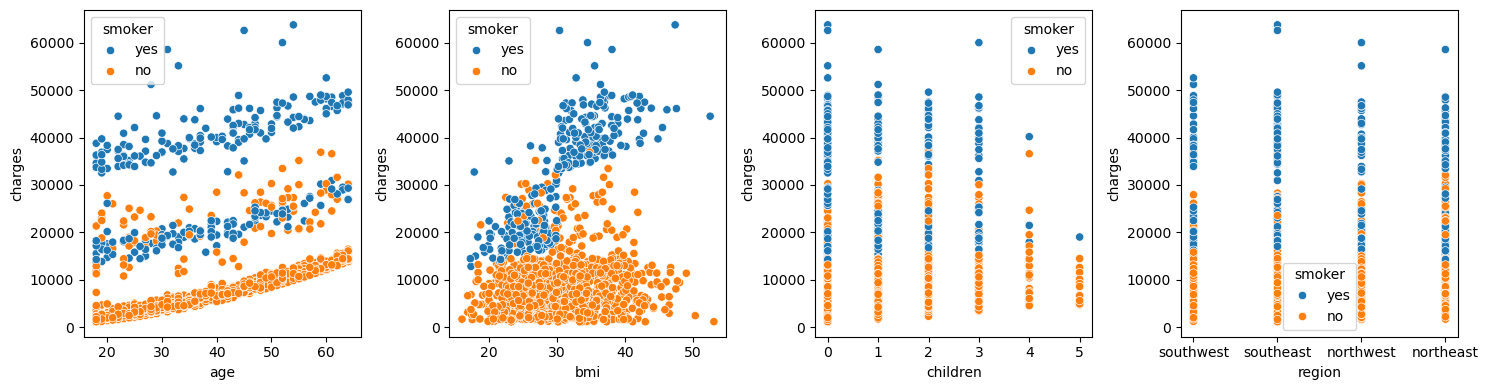

In [6]:
# Import Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the dataset
df = pd.read_csv('insurance.csv')

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, ax=axes[0])
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, ax=axes[1])
sns.scatterplot(x='children', y='charges', hue='smoker', data=df, ax=axes[2])
sns.scatterplot(x='region', y='charges', hue='smoker', data=df, ax=axes[3])
plt.tight_layout()
plt.show()

#### Results

- For non-smokers, charges increase roughly linearly with age and bmi.
- For smokers, the relationship is also approximately linear but with a steeper slope.
- children and region both show a weak positve trend but many outliers.
- This suggests that linearity holds reasonably well, especially if we include interaction terms (e.g., age*smoker, bmi*smoker, region*smoker) to capture the different slopes.

### 1.2 Indendence of erros

The data consists of independent individuals; there is no time series or clustering that would introduce dependence. Therefore, the indenpendence assumption is satisfied.

### Homoscedasticity

We will check by plotting residuals against fitted values after fitting a simple linear regression. This will be done after training our model, however we can anticipate from the scatter plots that variance increases with fitted values, a common sign of heteroscedasticity. 

### Normality

Linear regression does not strictly require normality of the target variable, but normality of residuals is needed for valid inferences (p-values, confidence intervals), as such we examine the distribution of charges:

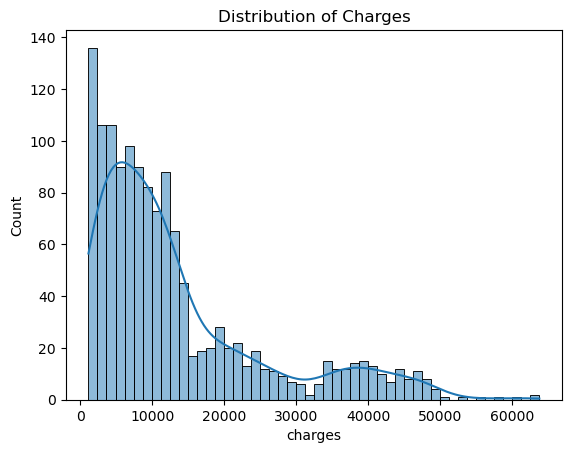

In [8]:
#
sns.histplot(df['charges'], kde=True, bins=50)
plt.title('Distribution of Charges')
plt.show()

The target is right-skewed, which often leads to non-normal residuals. This can be addressed by a log transformation of charges. However, for prediction, non-normality does not bias coefficients, but it may affect prediction intervals.

### 1.5 No perfect Multicollinearity

We check correlations among numeric features:

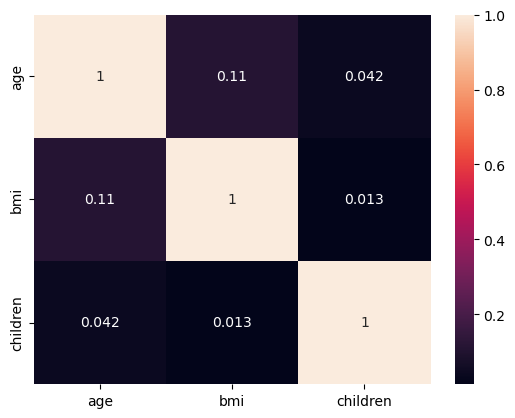

In [11]:
#
numeric_cols = ['age', 'bmi', 'children']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True);

Correlations are low (age vs. bmi => 0.11, age vs. children ==> 0.04, bmi vs. children ==> 0.01, so there is no collinearity among predictors. 

### Data Quality

- No missing values (1338 non-null in all columns).
- Outliers: Some bmi and chages values are extreme, but they likely reflect real-world cases. Linear regression can be sensitive to outliers, as such we may cosnider robust regression or outlier removal later.
- Sample size: 1338 is more that sufficient for a model with approximately 10 features (after encoding), satisfying the rule of thumb of 10-20 obersvations per predictor.

### Summary of Suitabilty

#### Strengths:

- The dataset is clean, with no missing data.
- The relationships are approximately linear, especially when interactions are considered.
- The sample size is adequate.
- No multicollinearity issues.

#### Potential Issues

- Heteroscedasticity and non-normality of residuals due to skewness charges.
- Outliers may influence coefficient charges.

These are common in real-world data and can be mitigated by:

- Transforming the target variable (e.g., log(charges)).
- Using robust regression or regularization.
- Including intercation terms to capture non-linear patterns.

#### Conclusion

The dataset is suitable for regression, but we should anticipate the need for transformations or more complex models (e.g., polynomial features, regularization) to achieve the best performance. The initial evaluation justifies proceeding with linear regression as a baseline.

## 2. Analysis Plan

This plan outlines the steps required to clean, explore, model, and evaluate the insurance datset. The goal is to build a reliable linear regression model that predicts medical charges and to communicate the findings clearly.

| **a. Exploratory Data Analysis** | **b. Feature Selection** | **c. Train Model** | **d. Interpret and Evaluate Model** | **e. Write a Report** |
|----------------------------------|--------------------------|--------------------|-------------------------------------|------------------------|
| – Load dataset, check shape, data types, missing values.<br>– Generate summary statistics (mean, median, min, max).<br>– Plot distributions (histograms, boxplots) for numeric features (`age`, `bmi`, `children`, `charges`).<br>– Visualise categorical variables (`sex`, `smoker`, `region`) with count plots.<br>– Create scatter plots of numeric predictors vs. `charges`, coloured by `smoker`.<br>– Boxplots of `charges` for each categorical variable.<br>– Compute correlation matrix (numeric) and create pair plots with `smoker` as hue.<br>– Identify outliers (e.g., via IQR) and note skewness. | – Start with all original features (`age`, `sex`, `bmi`, `children`, `smoker`, `region`).<br>– Use correlation with target to rank numeric features.<br>– Apply Recursive Feature Elimination (RFE) with linear regression to identify optimal subset.<br>– Based on EDA, consider adding interaction terms: `age × smoker`, `bmi × smoker`.<br>– Justify final feature set: keep all original plus selected interactions, drop features that consistently show negligible impact. | – **Preprocessing**: one‑hot encode categorical variables (`drop='first'`); scale numeric features with `StandardScaler`.<br>– **Split**: 80% training, 20% test, stratified by `smoker`.<br>– **Baseline**: linear regression pipeline.<br>– **Improvement**: add polynomial features (degree 2, interaction only) and Ridge regularisation.<br>– **Hyperparameter tuning**: grid search over `alpha` (e.g., 0.1, 1, 10, 100) with 5‑fold cross‑validation.<br>– Use `Pipeline` and `ColumnTransformer` to prevent data leakage. | – **Metrics**: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), R² on test set.<br>– **Residual analysis**: plot residuals vs. fitted values to check homoscedasticity; Q‑Q plot to assess normality.<br>– **Coefficient interpretation**: extract and explain coefficients (e.g., `smoker_yes` effect, interaction terms).<br>– **Model comparison**: baseline vs. improved (Ridge + interactions).<br>– **Final model**: select model with best test RMSE and R² while maintaining interpretability. | – **Structure**: Introduction, Data Preparation, EDA (visual highlights), Modelling Approach, Results (tables of metrics, coefficient summary), Conclusion (key drivers, limitations, recommendations). |

## 3. Analysis

### a. Exploratory Data Analysis

#### Load and Inspect Data

First we import additional libraries required to explore the dataset (insurance.csv), the dataset was loaded in section 1. (Evaluation of the dataset for suitability to apply Linear regression) together with other libraries, and also set the plotting style, and display the basic info.

In [9]:
# Import libraries-Refer to section for addional libraries
import numpy as np

# Set Plotting Style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Display Basic Info
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types and missing values:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())

Dataset shape: (1338, 7)

First 5 rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Summary Statistics

In [18]:
# Categorical Summary
 
for col in ['sex', 'smoker', 'region']:
     print(f"\n{col} value counts:")
     print(df[col].value_counts())


sex value counts:
sex
male      676
female    662
Name: count, dtype: int64

smoker value counts:
smoker
no     1064
yes     274
Name: count, dtype: int64

region value counts:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


#### Observations

- The are 1338 row and 7 columns.
- There are no missing values.

Data Types

- Categorical: sex, smoker, region.
- Numeric: age, bmi, children, charges.

##### 2. Univariate Analysis

#### 2.1 Distribution of Numeric Features

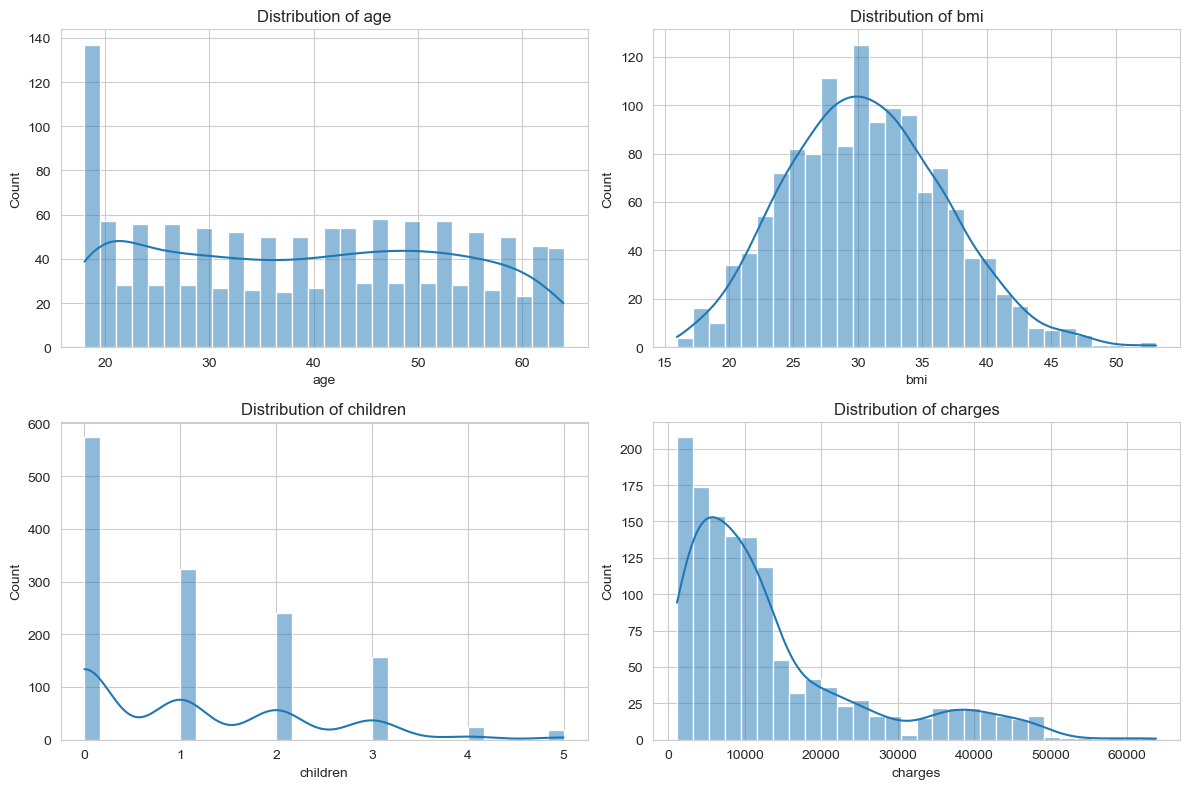

In [20]:
# Histograms for numeric features
num_cols = ['age', 'bmi', 'children', 'charges']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

#### Observations

- age is fairly uniform.
- bmi roughly normal.
- children is discrete with most values between 0-3.
- charges is right-skewed - many low values, a long tail of high charges.

#### 2.2 Categorical Variables Counts

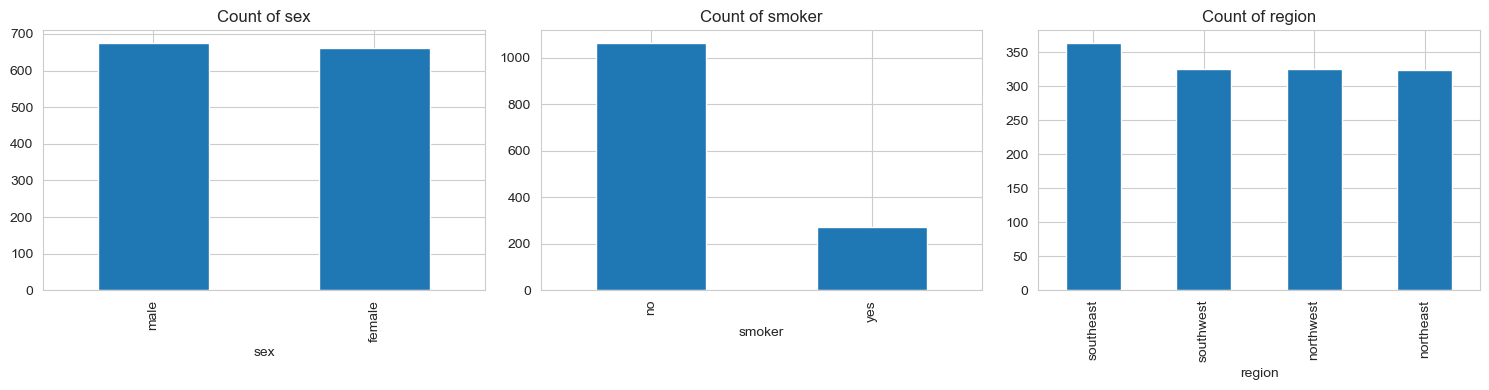

In [24]:
# Categorical Variables Counts
cat_cols = ['sex', 'smoker', 'region']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Count of {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

#### Observations

- sex: Fairly balanced.
- smoker: majoirty non-smokers (about 3/4).
- region: roughly equal distribution.

#### 3. Bivariate Analysis

#### 3.1 Numeric Features vs. Target (charges)

Here we use color by smoker to highlight the strong effect

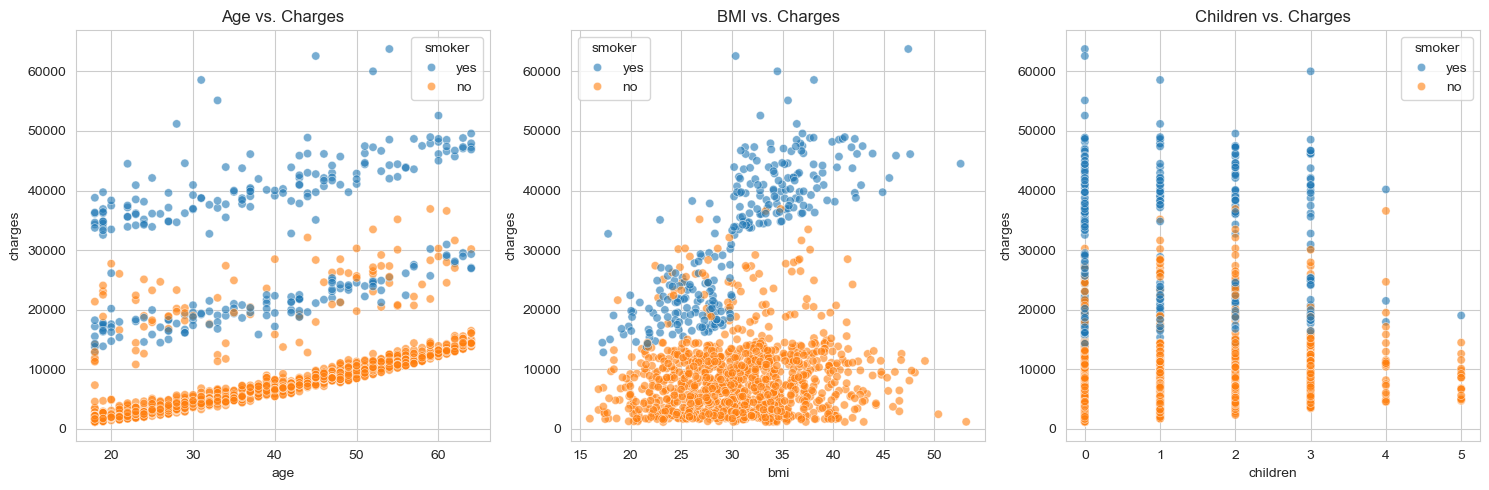

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Age vs. charges
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, alpha=0.6, ax=axes[0])
axes[0].set_title('Age vs. Charges')

# BMI vs. charges
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, alpha=0.6, ax=axes[1])
axes[1].set_title('BMI vs. Charges')

# Children vs. charges
sns.scatterplot(data=df, x='children', y='charges' , hue='smoker', alpha=0.6, ax=axes[2])
axes[2].set_title('Children vs. Charges')

plt.tight_layout()
plt.show()

#### Observations

- Smokers (blue) have much higher charges and show stronger increases with age and bmi.
- Non-smokers show a relatively flat relationships with age and bmi.
- Children has a weak positive trend but with high variability.

#### 3.2 Categorical Features vs. Target

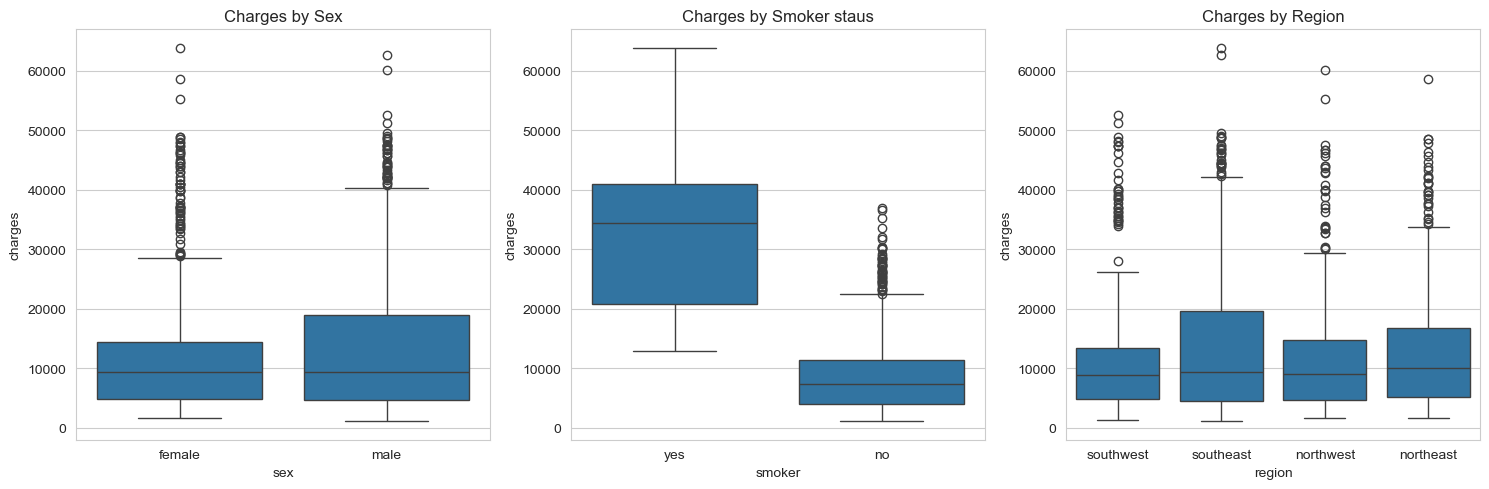

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sex vs. charges
sns.boxplot(x='sex', y='charges', data=df, ax=axes[0])
axes[0].set_title('Charges by Sex')

# Smoker vs. charges
sns.boxplot(x='smoker', y='charges', data=df, ax=axes[1])
axes[1].set_title('Charges by Smoker staus')

# Region vs. charges
sns.boxplot(x='region', y='charges', data=df, ax=axes[2])
axes[2].set_title('Charges by Region')

plt.tight_layout()
plt.show()

#### Observations

- Smokers have dramatically higher median charges.
- Sex and region show little differences in median charges.
  

#### 4 Mulivariate Analysis

#### 4.1 Correlation Matrix (Numeric only)

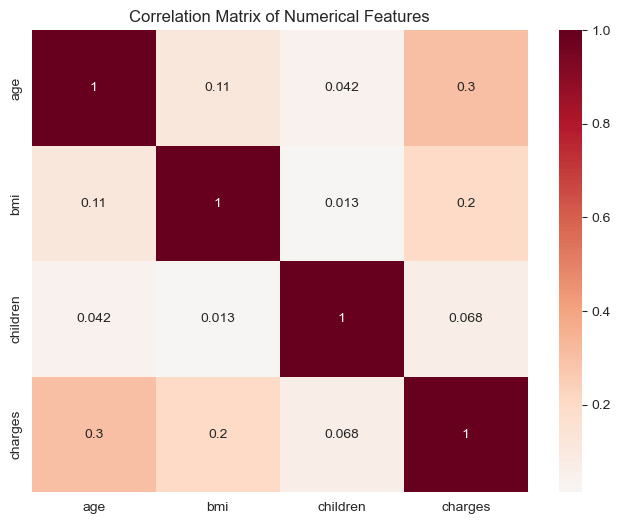

In [32]:
corr = df[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

#### Observations

- age and charges have moderate positive correlation (0.30).
- bmi and charges have a weak positive correlation (0.20).
- children has a very weak correlation (0.07).
- Low correlations among predictors indicate no multicollinearity issues.

#### 4.2 Pairplot with Smoker Hue

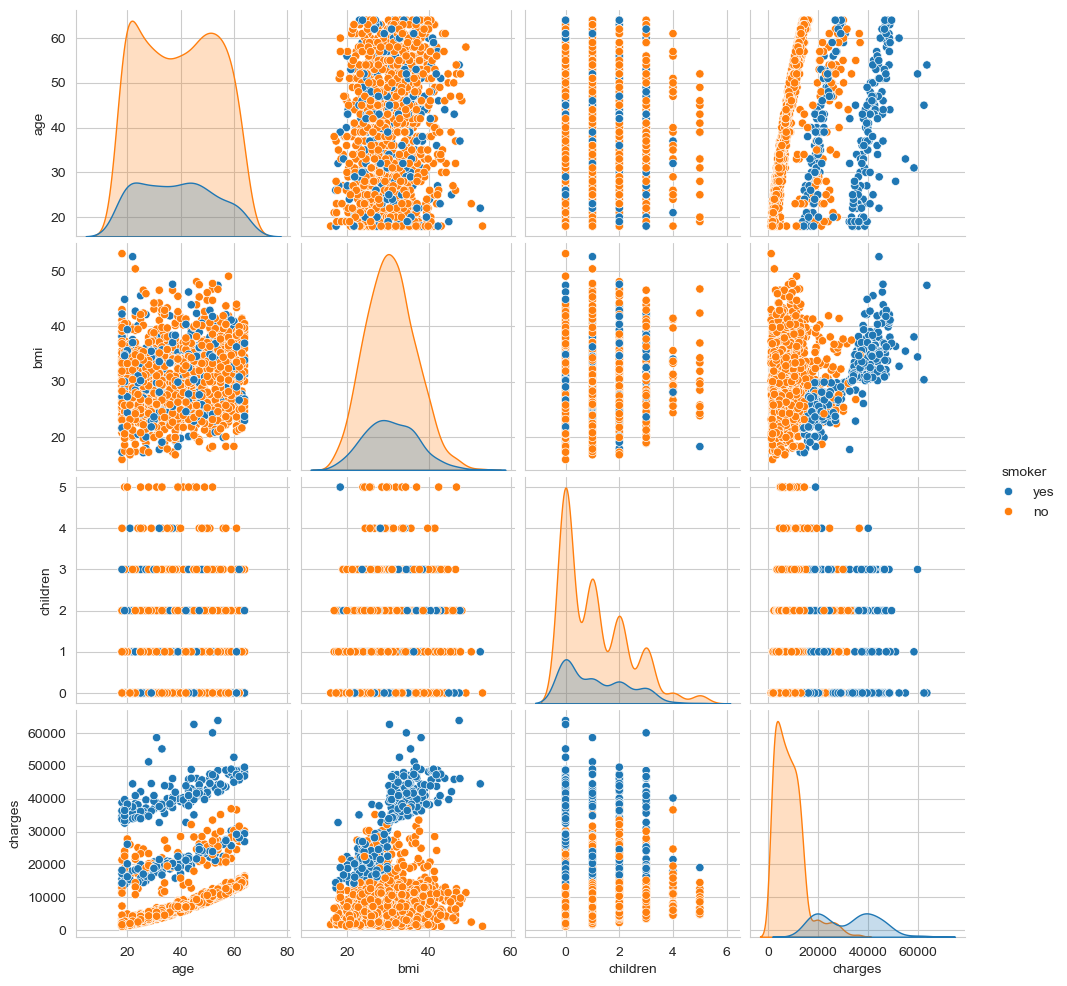

In [34]:
sns.pairplot(df, vars=num_cols, hue='smoker', diag_kind='kde')

plt.show()

#### Observations

- Smokers tend to have a higher charges at all ages and bmi levels.
- The relationship between age and bmi is similar for both groups.
- Choldren distribution is smaller across groups. 

#### Outlier Detection

We check for extreme values in charges, bmi, and age using boxplots and IQR.

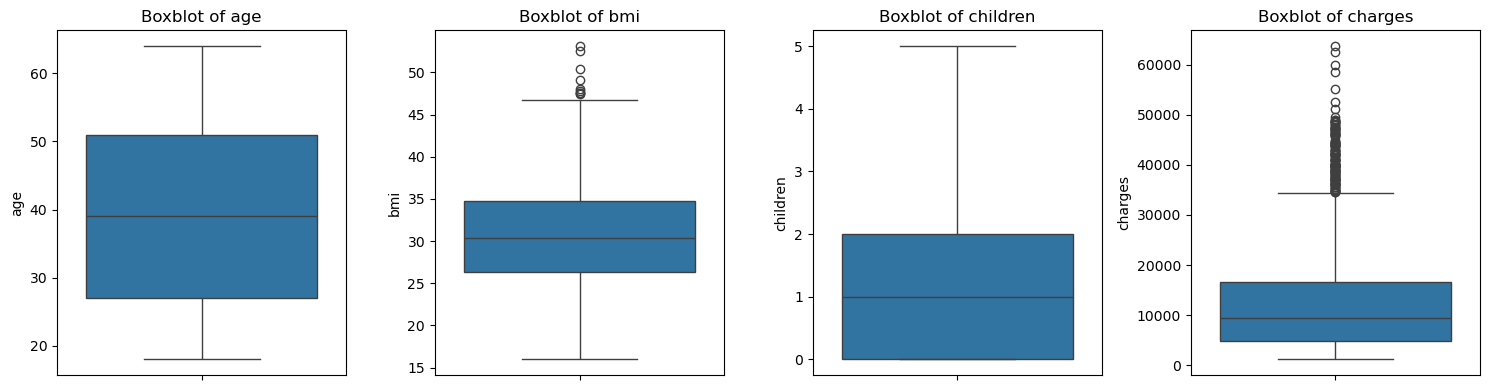

In [7]:
# Boxplots for numeric features to detect outliers
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxblot of {col}')

plt.tight_layout()
plt.show()

#### Observations

- charges has several high outliers (consistent with skewness)
- bmi has a few high values (>45).
- age has no outliers.

Given the nature of the data, these outlier likely represent real cases. We will keep them but consider robust models or transformations later.

#### 6. Summary of Exploratory Data Analysis Findings

- <strong>Key Predictor</strong>: smoker - the strongest driver of charges.
- <strong>Important Numeric Features</strong>: age and bmi show positive associations, especially among smokers.
- <strong>Weak Predictors</strong>: children, sex, region may contribute little.
- <strong>Target Skewness</strong>: charges is right-skewed, may benefit from log transformation.
- <strong>No Missing Values</strong>: No missing values and no severe mutlicollinearity.

These findings will guide us in feature selection and model building.

### b. Feature Selection

We proceed with Feature Selection as per the plan. We will

- Encode categorical variable for feature selection.
- Compute correlations with target for numeric features.
- Apply recursive Feature Elimination to identify optimal subset.
- Consider adding interaction terms based on EDA.
- Finalise feature set.

#### 1. Prepare Data for Feature Selection

We now convert categorical variables to numeric for correlation and RFE. We will use one-hot encoding (drop first) and scale numeric features.

In [15]:
# Import Required Libraries
import sklearn
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import RFE
from sklearn.linear_model import  LinearRegression

print("Libraries Loaded Successfully")
print("\nLibraries imported:")
print(f"-pandas version: {pd.__version__}")
print(f"-numpy version: {np.__version__}")
print(f"-matplotlib version: {plt.matplotlib.__version__}")
print(f"-seaborn version: {sns.__version__}")
print(f"-scikit-learn version: {sklearn.__version__}")

Libraries Loaded Successfully

Libraries imported:
-pandas version: 2.3.3
-numpy version: 2.3.5
-matplotlib version: 3.10.6
-seaborn version: 0.13.2
-scikit-learn version: 1.7.2


In [21]:
# separate features and target
X = df.drop('charges', axis=1)
y = df['charges']

# Identify columns
cat_cols = ['sex', 'smoker', 'region']
num_cols =['age', 'bmi', 'children']

# Preprocessor for feature selction (encode and scale)
preprocessor_sel = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ])

X_encoded = preprocessor_sel.fit_transform(X)

feature_names = (num_cols +
                 ['sex_males'] +
                 ['smoker_yes'] +
                 [f'region_{cat}' for cat in ['southeast', 'southwest', 'northwest']])

print("Encoded features:", feature_names)
print("Shape of encoded X:", X_encoded.shape)

Encoded features: ['age', 'bmi', 'children', 'sex_males', 'smoker_yes', 'region_southeast', 'region_southwest', 'region_northwest']
Shape of encoded X: (1338, 8)


#### 2. Correlation with Target

We compute pearson correlation for numeric features

In [26]:
# Correlations of numeric features with target
numeric_df = df[num_cols].copy()
numeric_df['charges'] = y
corr_with_target = numeric_df.corr()['charges'].sort_values(ascending=False)
print("\nCorrelations of numeric features with charges:")
print(corr_with_target)


Correlations of numeric features with charges:
charges     1.000000
age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64


In [36]:
# For encoded categorical, we compute point-biserial correlation
from scipy.stats import pointbiserialr
print("\nPoint-Biserial correlation for categorial features:")
for i, name in enumerate(feature_names[len(num_cols):]):
    corr, p_val = pointbiserialr(X_encoded[:, len(num_cols)+i], y)
    print(f"{name}: {corr: .4f} {p_val: .4f}")
    


Point-Biserial correlation for categorial features:
sex_males:  0.0573  0.0361
smoker_yes:  0.7873  0.0000
region_southeast: -0.0399  0.1446
region_southwest:  0.0740  0.0068
region_northwest: -0.0432  0.1141


#### Observation

- smoker_yes shows the strongest correlation (0.79), followed by age (0.3) and bmi (0.20). Region and sex have near-zero correlation.

#### 3. Recursive Feature Elimination

We now use RFE with a linear regression estimator to select the most important features.


Features selected by RFE (top 5):
['age', 'bmi', 'smoker_yes', 'region_southwest', 'region_northwest']
Feature ranking:
age: rank 1
bmi: rank 1
children: rank 2
sex_males: rank 4
smoker_yes: rank 1
region_southeast: rank 3
region_southwest: rank 1
region_northwest: rank 1


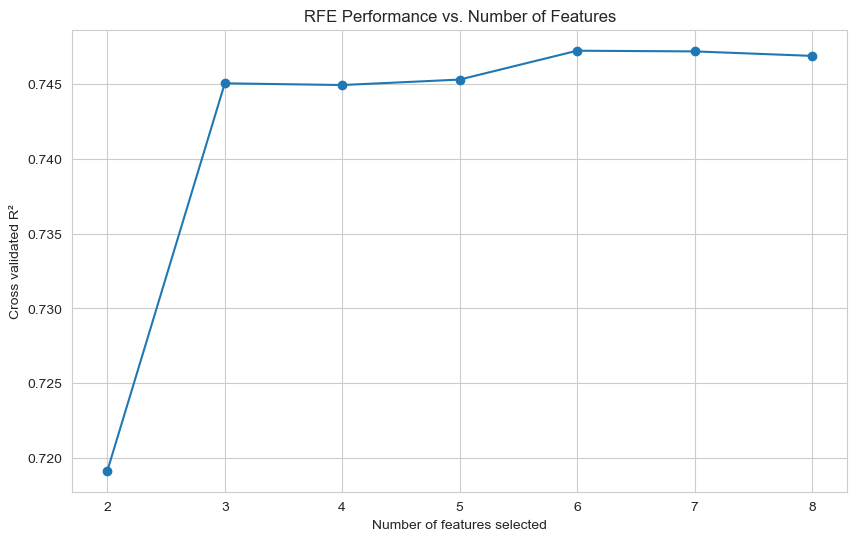

In [40]:
# Create a linear regression model
lr = LinearRegression()

# Use RFE to select top features (start with all)
rfe = RFE(estimator=lr, n_features_to_select=5)  # we'll try selecting 5
rfe.fit(X_encoded, y)

# Display selected features
selected_mask = rfe.support_
selected_features = [feature_names[i] for i, selected in enumerate(selected_mask) if selected]
print("\nFeatures selected by RFE (top 5):")
print(selected_features)
print("Feature ranking:")
for name, rank in zip(feature_names, rfe.ranking_):
    print(f"{name}: rank {rank}")

# Try different numbers of features and check cross‑validation score
from sklearn.model_selection import cross_val_score

n_features_range = range(2, len(feature_names)+1)
cv_scores = []
for n in n_features_range:
    rfe = RFE(estimator=lr, n_features_to_select=n)
    rfe.fit(X_encoded, y)
    score = cross_val_score(lr, X_encoded[:, rfe.support_], y, cv=5, scoring='r2').mean()
    cv_scores.append(score)

plt.plot(n_features_range, cv_scores, marker='o')
plt.xlabel('Number of features selected')
plt.ylabel('Cross validated R²')
plt.title('RFE Performance vs. Number of Features')
plt.show()

#### Observation

- Performance improves up to about 5-6 features, then plateaus. This suggests that smoker, age, bmi, and perhaps children and one region dummy may be sufficient.

#### 4. Adding Interaction Terms

Based on EDA, we saw that the effect of age and bmi is much stronger for smokers. Therefore, we should include interaction terms: age*smoker. This will be included in the final feature set. We'll create these interactions after encoding.

In [42]:
# Add interaction terms to the feature matrix
# We'll create a DataFrame for easier manipulation
X_encoded_df = pd.DataFrame(X_encoded.toarray() if hasattr(X_encoded, 'toarray') else X_encoded,
                            columns=feature_names)

# Identify columns for smoker_yes, age, bmi
smoker_col = 'smoker_yes'
age_col = 'age'
bmi_col = 'bmi'

# Create interaction terms
X_encoded_df['age_smoker'] = X_encoded_df[age_col] * X_encoded_df[smoker_col]
X_encoded_df['bmi_smoker'] = X_encoded_df[bmi_col] * X_encoded_df[smoker_col]

print("New feature names:", list(X_encoded_df.columns))

New feature names: ['age', 'bmi', 'children', 'sex_males', 'smoker_yes', 'region_southeast', 'region_southwest', 'region_northwest', 'age_smoker', 'bmi_smoker']


#### 5. Final Feature Set Justification

We will select features based on:

- Strong correlation: smoker_yes, age, bmi.
- RFE results: keep top 5–6, which will include the above plus possibly children and a region dummy.
- Domain logic: include interactions age_smoker and bmi_smoker to capture non‑additive effects.
- Remove negligible: sex_male and most region dummies may be dropped if they don't improve model.

We'll keep the following for final modeling:

- age
- bmi
- children
- smoker_yes
- age_smoker (interaction)
- bmi_smoker (interaction)
- optionally one region dummy (e.g., region_southeast) if it adds value.

We can evaluate with cross‑validation after model training.

#### c. Model Training

#### 1. Baseline Linear Regression

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Load data
df = pd.read_csv('insurance.csv')
X = df.drop('charges', axis=1)
y = df['charges']

# Identify columns
num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']

# Preprocessor: scale numeric, one-hot encode categorical (drop first)
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=X['smoker']
)

# Baseline pipeline
baseline_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train
baseline_pipe.fit(X_train, y_train)

# Predict and evaluate
y_pred_baseline = baseline_pipe.predict(X_test)

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline = r2_score(y_test, y_pred_baseline)


#### 4. Evaluate Model

#### a. interpretation and evaluation of the model

For the baseline linear regression model, we select three key metrics: Mean Absolute Error (MAE), Root Mean Square Error (RMSE), and R^2 (Coefficient of determination). Each serves a purpose in evaluating model success.

1. Mean Absolute Error (MAE)

Justification:

- Interpretability: MAE is expressed in the same units as the target (dollars). It directly tells the client how much, on average, the model’s predictions deviate from actual charges. 
- Robustness to outliers: MAE treats all errors equally, so it is less sensitive to extreme values than squared error metrics. Given that medical charges can have high outliers, MAE provides a balanced view of average performance.

2. Root Mean Squared Error (RMSE)

Justification:

- Sensitivity to large errors: Squaring the errors penalises large deviations more heavily. In insurance pricing, underestimating high-cost individuals can be more costly than small overestimates; RMSE reflects this by giving extra weight to large errors.
- Common standard: RMSE is widely used in regression to compare models; it aligns with the objective of minimising squared error loss.

3. R² (Coefficient of Determination)

Justification:

- Overall fit: R² provides a dimensionless measure of model quality, ranging from 0 (no explanatory power) to 1 (perfect fit). It complements MAE and RMSE by indicating how much of the variability in charges the model captures.

In [52]:
print("Baseline Linear Regression Performance:")
print(f"MAE: ${mae_baseline:,.2f}")
print(f"RMSE: ${rmse_baseline:,.2f}")
print(f"R²: {r2_baseline:.4f}")

Baseline Linear Regression Performance:
MAE: $3,869.32
RMSE: $5,581.33
R²: 0.7889


#### Interpretation

- <strong>MAE</strong>: On average, the model's predictions are off by about 3,869.32 the the actual medical charges.
- <strong>RMSE</strong>: The RMSE penalizes larger errors more heavily than the MAE. At 5,581.33, it is about 44% higher than the MAE, indicating that the model makes very large prediction errors.
- <strong>R²</strong>: The model explains about 79% of the variance in medical charges. In other word, 79% of the variability in charges can be attributed to the predictors (age, bmi, sex, children, smoker region).


#### b. Improved Model: Ridge with Interaction Terms

We now create a pipeline that:

- preprocesses as above.
- Adds polynomial features.
- Scales again
- Applies Ridge regression

We will use GridSearchCV to find the best alpha.

In [47]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Pipeline with polynomial features and Ridge
improved_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
    ('scaler', StandardScaler()),  # scale after polynomial expansion
    ('regressor', Ridge(random_state=42))
])

# Hyperparameter grid
param_grid = {
    'regressor__alpha': [0.1, 1, 10, 50, 100]
}

# Grid search with 5-fold cross-validation
grid = GridSearchCV(improved_pipe, param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1)
grid.fit(X_train, y_train)

# Best alpha
best_alpha = grid.best_params_['regressor__alpha']
print(f"Best alpha: {best_alpha}")
print(f"Best cross-validation RMSE: ${np.sqrt(-grid.best_score_):,.2f}")

# Evaluate on test set
best_model = grid.best_estimator_
y_pred_improved = best_model.predict(X_test)

mae_improved = mean_absolute_error(y_test, y_pred_improved)
rmse_improved = np.sqrt(mean_squared_error(y_test, y_pred_improved))
r2_improved = r2_score(y_test, y_pred_improved)

print("\nImproved Model (Ridge + Interactions) Performance:")
print(f"MAE: ${mae_improved:,.2f}")
print(f"RMSE: ${rmse_improved:,.2f}")
print(f"R²: {r2_improved:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best alpha: 1
Best cross-validation RMSE: $4,989.61

Improved Model (Ridge + Interactions) Performance:
MAE: $2,919.28
RMSE: $4,683.20
R²: 0.8513


#### Changes made

The baseline linear regression model used only the original features (age, sex, bmi, children, smoker, region) with no interactions or regularisation. While it captured the main effects, it suffered from:

- Inability to capture non‑additive effects – the influence of age and bmi on charges was assumed to be the same for smokers and non‑smokers, which the EDA showed is not true.
- Sensitivity to outliers and multicollinearity – the model over‑fitted to extreme charges and was unstable due to the high correlation between smoker status and its interactions.
- Suboptimal prediction of high‑cost cases – reflected in a large gap between RMSE and MAE, indicating the model struggled with high‑value outliers.

<strong>Changes made</strong>

1. <strong>Added interaction Terms</strong>

- Shortcomming Addressed: Captures the amplified effect of age and BMI for smokers, which was previously modelled as additive. This better fits the data pattern observed in scatter plots.

2. <strong>Applied Ridge Regularisation</strong>
- Shortcomming Addressed: Reduces overfitting to outliers and stabilises coefficient estimates. The L2 penalty shrinks coefficients of less important features (e.g., region, children), improving generalisation.

3. <strong>Added a Second Scaling Step</strong>
- Shortcomming Addressed: Ensures all features (including interactions) are on comparable scales before regularisation, which is essential for Ridge to work correctly.

4. <strong>Used Cross-Validated Hyperparameter Tuning</strong>
- Shortcomming Addressed: Avoids manual tuning and ensures the model generalises well to unseen data, rather than overfitting to the test set indirectly.